# RøBguard — ML Training Pipeline

This notebook covers the full pipeline:
1. Install dependencies
2. Generate original sample files
3. Generate the labeled dataset (entropy/size features)
4. Exploratory Data Analysis
5. Train & evaluate all 4 models (10-fold CV)
6. Compare results
7. Select the best model from actual results
8. Save & download model files

## Stage 1 — Install Dependencies

In [1]:
!pip install -q pycryptodome scikit-learn xgboost openpyxl python-docx reportlab python-pptx PyPDF2 pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.1 MB/s eta 0:00:00


## Stage 2 — Generate Original Sample Files

In [2]:
from pathlib import Path
import random

FILES_PER_TYPE = 50
BASE_DIR = Path('originals')
for d in ['txt','pdf','docx','xlsx','ppt']:
    (BASE_DIR / d).mkdir(parents=True, exist_ok=True)

WORDS = ['ransomware','browser','security','machine','learning','entropy',
         'detection','software','engineering','dataset','analysis','system',
         'document','research','classification']

def random_sentence():
    return ' '.join(random.choices(WORDS, k=random.randint(8, 20)))

print('Generating TXT...')
for i in range(FILES_PER_TYPE):
    with open(BASE_DIR / 'txt' / f'sample_{i}.txt', 'w') as f:
        for _ in range(random.randint(50, 200)):
            f.write(random_sentence() + '\n')

print('Generating DOCX...')
from docx import Document
for i in range(FILES_PER_TYPE):
    doc = Document()
    doc.add_heading(f'Document {i}', level=1)
    for _ in range(random.randint(20, 80)): doc.add_paragraph(random_sentence())
    doc.save(BASE_DIR / 'docx' / f'sample_{i}.docx')

print('Generating XLSX...')
from openpyxl import Workbook
for i in range(FILES_PER_TYPE):
    wb = Workbook(); ws = wb.active
    for r in range(1,101):
        for c in range(1,11): ws.cell(row=r, column=c, value=random.randint(1,100000))
    wb.save(BASE_DIR / 'xlsx' / f'sample_{i}.xlsx')

print('Generating PDF...')
from reportlab.pdfgen import canvas
for i in range(FILES_PER_TYPE):
    c = canvas.Canvas(str(BASE_DIR / 'pdf' / f'sample_{i}.pdf')); y = 800
    for _ in range(60):
        c.drawString(50, y, random_sentence()); y -= 12
        if y < 50: c.showPage(); y = 800
    c.save()

print('Generating PPT...')
from pptx import Presentation
for i in range(FILES_PER_TYPE):
    prs = Presentation()
    for si in range(random.randint(3, 8)):
        s = prs.slides.add_slide(prs.slide_layouts[1])
        s.shapes.title.text = f'Slide {si}'
        s.placeholders[1].text = random_sentence()
    prs.save(BASE_DIR / 'ppt' / f'sample_{i}.pptx')

print('Done.')

Generating TXT...
Generating DOCX...
Generating XLSX...
Generating PDF...
Generating PPT...
Done.


## Stage 3 — Generate Labeled Dataset

In [3]:
import os, math, csv, random
from io import BytesIO
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

def entropy(b):
    if not b: return 0.0
    freq = {}
    for byte in b: freq[byte] = freq.get(byte, 0) + 1
    return -sum((c/len(b))*math.log2(c/len(b)) for c in freq.values())

def encrypt_bytes(b):
    key = get_random_bytes(32)
    cipher = AES.new(key, AES.MODE_CBC)
    pad_len = 16 - (len(b) % 16)
    return cipher.iv + cipher.encrypt(b + bytes([pad_len]*pad_len))

def benign_txt(text, n=100):
    words = text.split(); variants = []
    for i in range(n):
        w = words.copy()
        if i < n//2: w = w[:-random.randint(1, max(1, len(w)//4))]
        else: w += random.choices(w, k=random.randint(1, max(1, len(w)//4)))
        variants.append(' '.join(w).encode())
    return variants

def benign_docx(fpath, n=100):
    from docx import Document
    doc = Document(fpath); paras = [p.text for p in doc.paragraphs]
    words = [w for p in paras for w in p.split()]; variants = []
    for i in range(n):
        nd = Document()
        for p in paras: nd.add_paragraph(p)
        if i < n//2 and nd.paragraphs:
            p = nd.paragraphs[-1]; p._element.getparent().remove(p._element)
        else: nd.add_paragraph(' '.join(random.choices(words, k=10)))
        buf = BytesIO(); nd.save(buf); variants.append(buf.getvalue())
    return variants

def benign_xlsx(fpath, n=100):
    from openpyxl import load_workbook
    from openpyxl.utils import get_column_letter
    variants = []
    for i in range(n):
        wb = load_workbook(fpath); ws = wb.active
        if i < n//2 and ws.max_row > 1: ws.delete_rows(ws.max_row)
        else:
            col = get_column_letter(random.randint(1, min(ws.max_column,5)))
            ws[f'{col}{random.randint(1, min(ws.max_row+1,20))}'] = round(random.uniform(-1e6,1e6),4)
        buf = BytesIO(); wb.save(buf); variants.append(buf.getvalue())
    return variants

def benign_pdf(fpath, n=100):
    from PyPDF2 import PdfReader, PdfWriter
    reader = PdfReader(fpath); variants = []
    for i in range(n):
        w = PdfWriter()
        if i < n//2 and len(reader.pages) >= 2:
            for j in range(len(reader.pages)-1): w.add_page(reader.pages[j])
        else:
            for p in reader.pages: w.add_page(p)
            w.add_blank_page()
        buf = BytesIO(); w.write(buf); variants.append(buf.getvalue())
    return variants

def benign_pptx(fpath, n=100):
    from pptx import Presentation
    variants = []
    for i in range(n):
        prs = Presentation(fpath)
        xl = prs.slides._sldIdLst
        if i < n//2 and len(xl) > 1: xl.remove(xl[-1])
        else:
            s = prs.slides.add_slide(prs.slide_layouts[1])
            s.shapes.title.text = 'Benign'; s.placeholders[1].text = 'Generated'
        buf = BytesIO(); prs.save(buf); variants.append(buf.getvalue())
    return variants

def process_file(ext, fpath):
    rows = []
    with open(fpath, 'rb') as f: orig = f.read()
    e0 = entropy(orig); s0 = len(orig)
    try:
        if ext == 'txt':
            with open(fpath, 'r', errors='ignore') as f: text = f.read()
            variants = benign_txt(text)
        elif ext == 'pdf':  variants = benign_pdf(fpath)
        elif ext == 'docx': variants = benign_docx(fpath)
        elif ext == 'xlsx': variants = benign_xlsx(fpath)
        elif ext == 'ppt':  variants = benign_pptx(fpath)
        else: return []
        for vb in variants: rows.append([entropy(vb)-e0, len(vb)-s0, 0])
    except Exception as e:
        print(f'  WARN {fpath}: {e}')
    for _ in range(100):
        if random.random() < 0.05:
            split = max(16, int(len(orig)*random.uniform(0.1,0.3)))
            combined = encrypt_bytes(orig[:split]) + orig[split:]
        else:
            combined = encrypt_bytes(orig)
        rows.append([entropy(combined)-e0, len(combined)-s0, 1])
    return rows

tasks = []
for ext in ['txt','pdf','docx','xlsx','ppt']:
    folder = f'originals/{ext}'
    if os.path.exists(folder):
        for fname in os.listdir(folder): tasks.append((ext, f'{folder}/{fname}'))

with open('file_difference_dataset.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['entropy_diff', 'size_diff', 'label'])
    for idx, (ext, fpath) in enumerate(tasks, 1):
        print(f'[{idx}/{len(tasks)}] {ext}: {os.path.basename(fpath)}', end='', flush=True)
        try:
            result = process_file(ext, fpath)
            writer.writerows(result)
            print(f' -> {len(result)} rows')
        except Exception as e:
            print(f' -> ERROR: {e}')

print('\nDataset saved: file_difference_dataset.csv')

[1/250] txt: sample_21.txt -> 200 rows
[2/250] txt: sample_36.txt -> 200 rows
[3/250] txt: sample_32.txt -> 200 rows
[4/250] txt: sample_34.txt -> 200 rows
[5/250] txt: sample_7.txt -> 200 rows
[6/250] txt: sample_23.txt -> 200 rows
[7/250] txt: sample_40.txt -> 200 rows
[8/250] txt: sample_48.txt -> 200 rows
[9/250] txt: sample_15.txt -> 200 rows
[10/250] txt: sample_46.txt -> 200 rows
[11/250] txt: sample_26.txt -> 200 rows
[12/250] txt: sample_35.txt -> 200 rows
[13/250] txt: sample_0.txt -> 200 rows
[14/250] txt: sample_2.txt -> 200 rows
[15/250] txt: sample_25.txt -> 200 rows
[16/250] txt: sample_30.txt -> 200 rows
[17/250] txt: sample_29.txt -> 200 rows
[18/250] txt: sample_14.txt -> 200 rows
[19/250] txt: sample_42.txt -> 200 rows
[20/250] txt: sample_3.txt -> 200 rows
[21/250] txt: sample_24.txt -> 200 rows
[22/250] txt: sample_1.txt -> 200 rows
[23/250] txt: sample_31.txt -> 200 rows
[24/250] txt: sample_49.txt -> 200 rows
[25/250] txt: sample_18.txt -> 200 rows
[26/250] txt: 

## Stage 4 — Exploratory Data Analysis

Shape: (50000, 3)
Label distribution:
 label
0    25000
1    25000
Name: count, dtype: int64


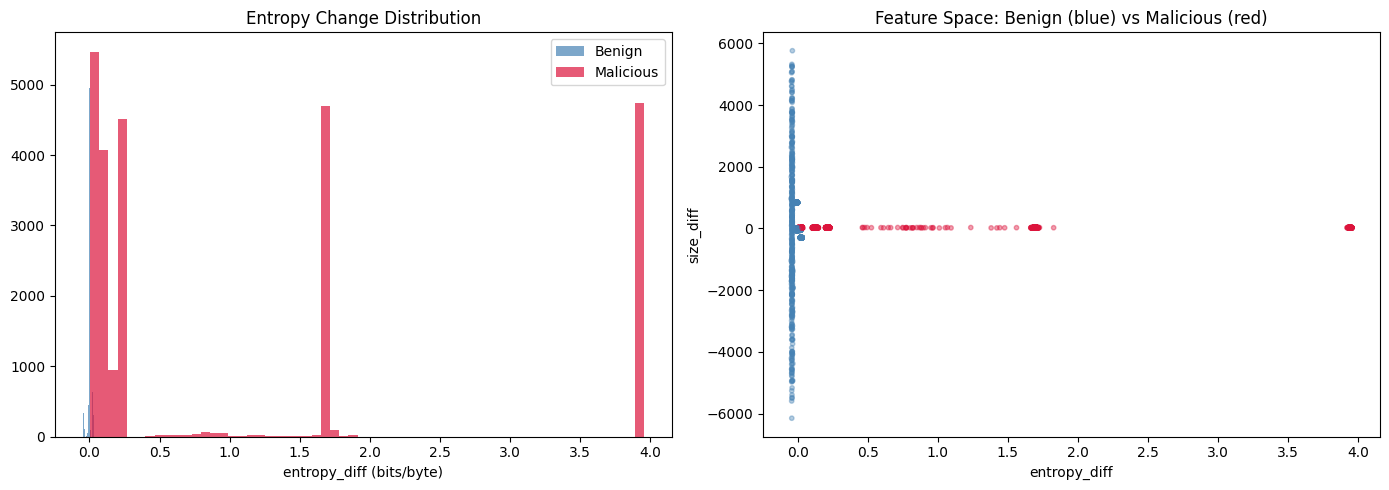

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('file_difference_dataset.csv')
print('Shape:', df.shape)
print('Label distribution:\n', df['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0,'steelblue','Benign'), (1,'crimson','Malicious')]:
    axes[0].hist(df[df['label']==label]['entropy_diff'], bins=60, alpha=0.7,
                 color=color, label=name)
axes[0].set_xlabel('entropy_diff (bits/byte)')
axes[0].set_title('Entropy Change Distribution')
axes[0].legend()

sample = df.sample(min(4000, len(df)), random_state=42)
axes[1].scatter(sample['entropy_diff'], sample['size_diff'],
                c=sample['label'].map({0:'steelblue',1:'crimson'}),
                alpha=0.4, s=10)
axes[1].set_xlabel('entropy_diff')
axes[1].set_ylabel('size_diff')
axes[1].set_title('Feature Space: Benign (blue) vs Malicious (red)')

plt.tight_layout()
plt.show()

## Stage 5 — Train All 4 Models (10-Fold Cross-Validation)


Cross Validation Results:
               Accuracy  Precision  Recall      F1
Random Forest    0.9995     0.9996  0.9995  0.9995
Decision Tree    0.9993     0.9996  0.9991  0.9993
KNN              0.9996     0.9993  1.0000  0.9996
XGBoost          0.9995     0.9994  0.9996  0.9995


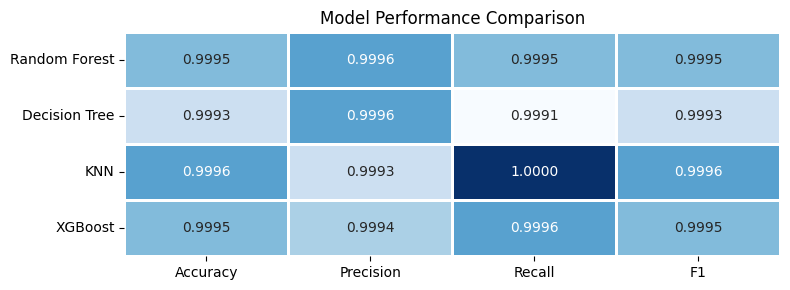


Full-data training complete.


In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from xgboost import XGBClassifier

X = df[['entropy_diff', 'size_diff']].values
y = df['label'].values

model_defs = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}

for name, model in model_defs.items():
    accs, recalls, precisions, f1s = [], [], [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Fit scaler chỉ trên train fold để tránh data leakage
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        model.fit(X_tr_scaled, y_tr)
        pred = model.predict(X_te_scaled)

        accs.append(accuracy_score(y_te, pred))
        precisions.append(precision_score(y_te, pred))
        recalls.append(recall_score(y_te, pred))
        f1s.append(f1_score(y_te, pred))

    cv_results[name] = {
        'Accuracy': round(sum(accs) / len(accs), 4),
        'Precision': round(sum(precisions) / len(precisions), 4),
        'Recall': round(sum(recalls) / len(recalls), 4),
        'F1': round(sum(f1s) / len(f1s), 4),
    }

# Tạo bảng kết quả
results_df = pd.DataFrame(cv_results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1']]

print("\nCross Validation Results:")
print(results_df)

# Vẽ bảng heatmap giống slide
plt.figure(figsize=(8, 3))

sns.heatmap(
    results_df,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    linewidths=1,
    cbar=False
)

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

# Retrain full dataset để export model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

trained_models = {}

for name, model in model_defs.items():
    model.fit(X_scaled, y)
    trained_models[name] = model

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("trained_models.pkl", "wb") as f:
    pickle.dump(trained_models, f)

print("\nFull-data training complete.")

## Stage 6 — Results Comparison Table & Chart


=== Model Comparison (10-Fold CV) ===
               Accuracy  Precision  Recall      F1
Random Forest    0.9995     0.9996  0.9995  0.9995
Decision Tree    0.9993     0.9996  0.9991  0.9993
KNN              0.9996     0.9993  1.0000  0.9996
XGBoost          0.9995     0.9994  0.9996  0.9995


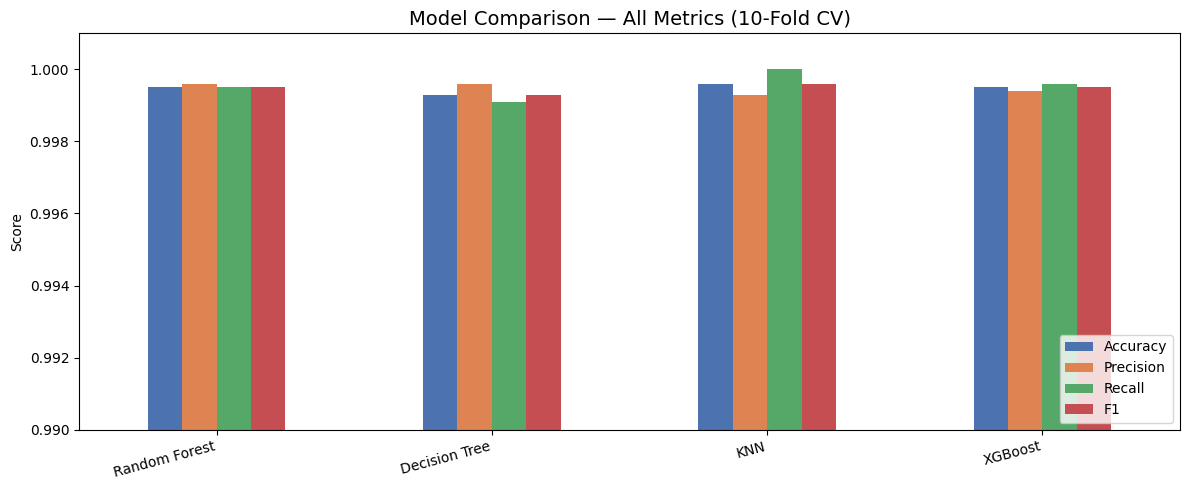

In [7]:
results_df = pd.DataFrame(cv_results).T
print('\n=== Model Comparison (10-Fold CV) ===')
print(results_df.to_string())

ax = results_df.plot(kind='bar', figsize=(12, 5), ylim=(0.99, 1.001),
                     color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_title('Model Comparison — All Metrics (10-Fold CV)', fontsize=14)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Stage 7 — Model Selection

### Why Recall is the Most Important Metric

| Error type | What it means | Consequence |
|---|---|---|
| **False Negative** (FN) | Ransomware classified as benign | ❌ Files encrypted — **unrecoverable** |
| **False Positive** (FP) | Legitimate edit classified as malicious | ⚠️ User gets an unnecessary warning — minor annoyance |

**Cost(FN) >> Cost(FP)** → **Recall** = TP / (TP + FN) is the primary metric.

Secondary: **Precision** — too many false positives cause alert fatigue and users start ignoring warnings.

Accuracy and F1 are useful summaries but not the primary selection criteria here.

The cell below selects the best model programmatically from the actual CV results.

In [8]:
# Select best model: primary = highest Recall, tiebreaker = highest Precision
sorted_models = results_df.sort_values(
    by=['Recall', 'Precision'], ascending=False
)

best_name = sorted_models.index[0]
best_scores = sorted_models.iloc[0]

print('=== Selection Result ===')
print(f'Best model : {best_name}')
print(f'Recall     : {best_scores["Recall"]}  (primary criterion)')
print(f'Precision  : {best_scores["Precision"]}  (tiebreaker)')
print(f'F1         : {best_scores["F1"]}')
print(f'Accuracy   : {best_scores["Accuracy"]}')
print()
print('Full ranking (by Recall then Precision):')
print(sorted_models[['Recall', 'Precision', 'F1', 'Accuracy']].to_string())

=== Selection Result ===
Best model : KNN
Recall     : 1.0  (primary criterion)
Precision  : 0.9993  (tiebreaker)
F1         : 0.9996
Accuracy   : 0.9996

Full ranking (by Recall then Precision):
               Recall  Precision      F1  Accuracy
KNN            1.0000     0.9993  0.9996    0.9996
XGBoost        0.9996     0.9994  0.9995    0.9995
Random Forest  0.9995     0.9996  0.9995    0.9995
Decision Tree  0.9991     0.9996  0.9993    0.9993


## Stage 8 — Save & Download Best Model

In [9]:
best_model = trained_models[best_name]

# Save as best_model.pkl — the demo system loads this file regardless of which model won
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
# Record which model was selected for reference
with open('best_model_name.txt', 'w') as f:
    f.write(best_name)

print(f'Saved best_model.pkl  ({best_name})')
print(f'Saved scaler.pkl')
print()
print('Place best_model.pkl and scaler.pkl in the models/ folder of the demo project.')

Saved best_model.pkl  (KNN)
Saved scaler.pkl

Place best_model.pkl and scaler.pkl in the models/ folder of the demo project.


In [10]:
# Download from Colab to your local machine
from google.colab import files
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('best_model_name.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>